# Used Car Price Prediction

## 1. Project Goal

The goal of this project is to build a regression model that predicts used car prices based on vehicle features such as year, mileage, fuel type, transmission, seller type, ownership history, and other car-related information.

## 2. Import Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

## 3. Load Dataset

In [2]:
df = pd.read_csv('../data/raw/used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 4. Basic Data Exploration

In [3]:
df.shape

(4009, 12)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [22]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

## 5. Data Cleaning

In this section, the dataset is cleaned before modeling. The `price` and `milage` columns are converted from text into numeric format, and missing categorical values are filled with `Unknown`.

In [29]:
df_clean = df.copy()

df_clean["price"].head(10)

0    $10,300
1    $38,005
2    $54,598
3    $15,500
4    $34,999
5    $14,798
6    $31,000
7     $7,300
8    $41,927
9    $69,950
Name: price, dtype: str

In [30]:
df_clean["price"] = (df_clean["price"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float))
df_clean["price"].head(10)

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
5    14798.0
6    31000.0
7     7300.0
8    41927.0
9    69950.0
Name: price, dtype: float64

In [31]:
df_clean["milage"].head(10)

0     51,000 mi.
1     34,742 mi.
2     22,372 mi.
3     88,900 mi.
4      9,835 mi.
5    136,397 mi.
6     84,000 mi.
7    242,000 mi.
8     23,436 mi.
9     34,000 mi.
Name: milage, dtype: str

In [32]:
df_clean["milage"] = (
    df_clean["milage"]
    .str.replace(" mi.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float))

df_clean["milage"].head(10)

0     51000.0
1     34742.0
2     22372.0
3     88900.0
4      9835.0
5    136397.0
6     84000.0
7    242000.0
8     23436.0
9     34000.0
Name: milage, dtype: float64

In [33]:
categorical_missing_columns = ["fuel_type", "accident", "clean_title"]

for col in categorical_missing_columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

In [34]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   str    
 1   model         4009 non-null   str    
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     4009 non-null   str    
 5   engine        4009 non-null   str    
 6   transmission  4009 non-null   str    
 7   ext_col       4009 non-null   str    
 8   int_col       4009 non-null   str    
 9   accident      4009 non-null   str    
 10  clean_title   4009 non-null   str    
 11  price         4009 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 376.0 KB


In [35]:
df_clean.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [38]:
df_clean[["price", "milage"]].describe()

,price,milage
count,4.009000e+03,4009.000000
mean,4.455319e+04,64717.551010
std,7.871064e+04,52296.599459
min,2.000000e+03,100.000000
25%,1.720000e+04,23044.000000
50%,3.100000e+04,52775.000000
75%,4.999000e+04,94100.000000
max,2.954083e+06,405000.000000


## 6. Feature Engineering

In this section, new useful features are created from the existing columns. A `car_age` feature is created from `model_year` because the age of a car is usually more useful for price prediction than the year alone.

In [40]:
current_year = pd.Timestamp.now().year
df_clean["car_age"] = current_year - df_clean["model_year"]
df_clean[["car_age", "model_year"]].head(10)

,car_age,model_year
0,13,2013
1,5,2021
2,4,2022
3,11,2015
4,5,2021
5,10,2016
6,9,2017
7,25,2001
8,5,2021
9,6,2020


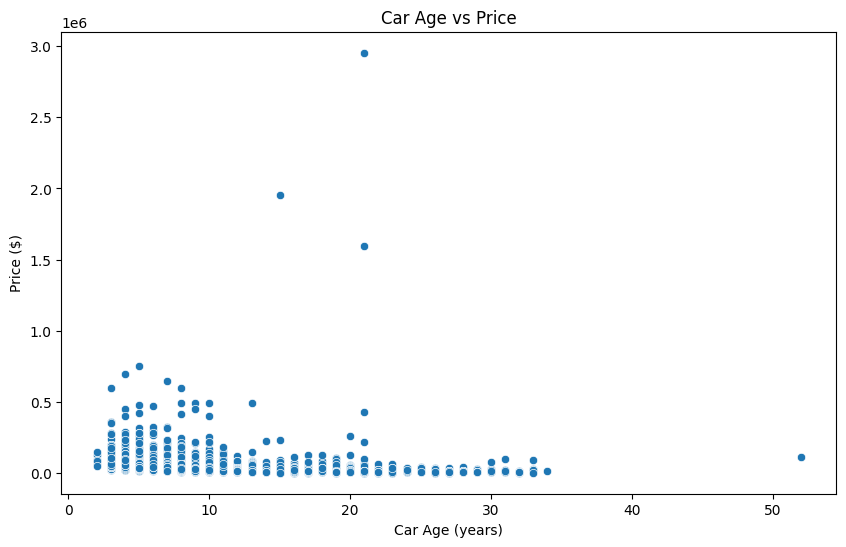

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="car_age", y="price", data=df_clean)
plt.title("Car Age vs Price")
plt.xlabel("Car Age (years)")
plt.ylabel("Price ($)")
plt.show()

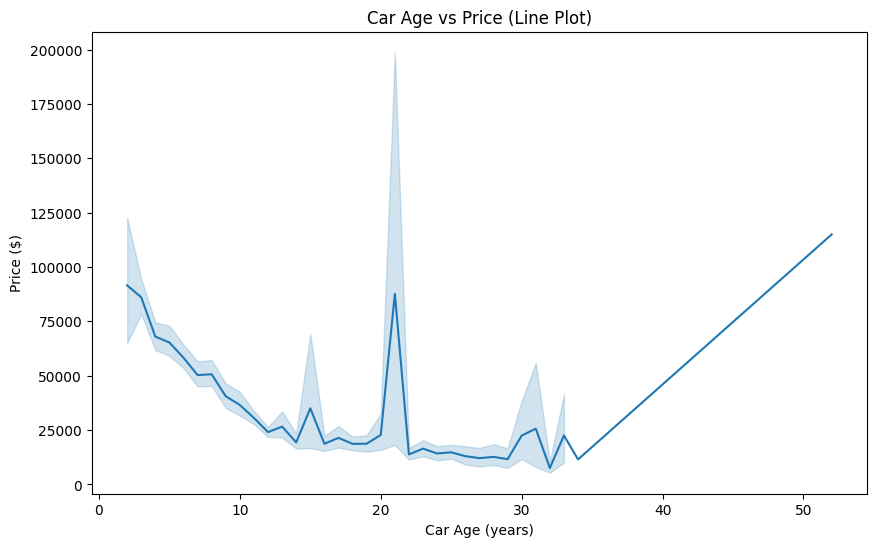

In [42]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="car_age", y="price", data=df_clean)
plt.title("Car Age vs Price (Line Plot)")
plt.xlabel("Car Age (years)")
plt.ylabel("Price ($)")
plt.show()

In [43]:
df_clean["mileage_per_year"] = df_clean["milage"] / df_clean["car_age"].replace(0,1)
df_clean[["mileage_per_year", "milage", "car_age"]].head(10)

,mileage_per_year,milage,car_age
0,3923.076923,51000.0,13
1,6948.400000,34742.0,5
2,5593.000000,22372.0,4
3,8081.818182,88900.0,11
4,1967.000000,9835.0,5
5,13639.700000,136397.0,10
6,9333.333333,84000.0,9
7,9680.000000,242000.0,25
8,4687.200000,23436.0,5
9,5666.666667,34000.0,6


In [44]:
df_clean["mileage_per_year"].describe()

count     4009.000000
mean      5993.281538
std       3782.668958
min         25.000000
25%       3189.296296
50%       5530.800000
75%       8187.777778
max      39900.000000
Name: mileage_per_year, dtype: float64

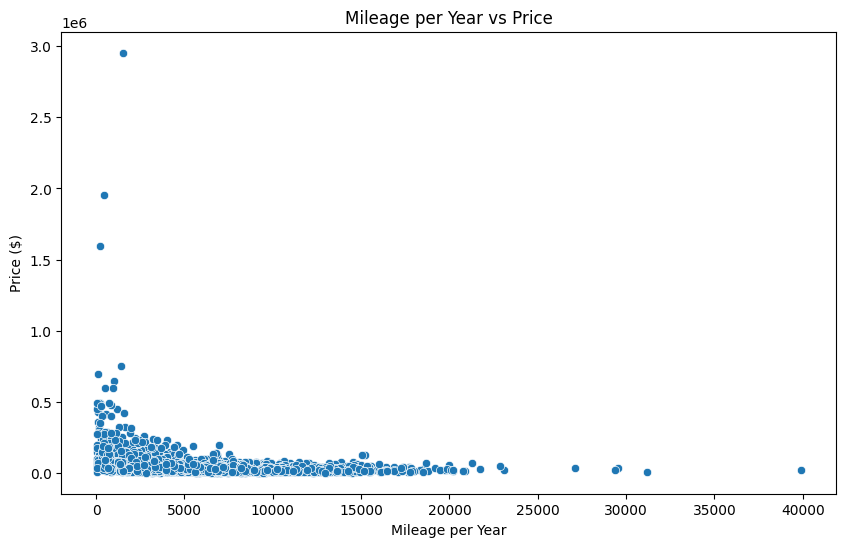

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="mileage_per_year", y="price", data=df_clean)
plt.title("Mileage per Year vs Price")
plt.xlabel("Mileage per Year")
plt.ylabel("Price ($)")
plt.show()

The `car_age` feature was created to represent how old each car is. The `mileage_per_year` feature was also created to show how much the car was driven per year on average. These features may help the model better understand car depreciation and usage.

## 7. Feature Selection and Encoding

In this section, useful input features are selected for the model. Numeric features are used directly, and categorical features are converted into numeric columns using one-hot encoding.

In [47]:
features = [
    "brand", 
    "model_year",
    "model", 
    "milage",
    "car_age",
    "mileage_per_year",
    "fuel_type",
    "accident",
    "clean_title",
    "engine", 
    "transmission",
    "ext_col",
    "int_col"
]
target = "price"
X = df_clean[features]
y = df_clean[target]

X.head()

,brand,model_year,model,milage,car_age,mileage_per_year,fuel_type,accident,clean_title,engine,transmission,ext_col,int_col
0,Ford,2013,Utility Police Interceptor Base,51000.0,13,3923.076923,E85 Flex Fuel,At least 1 accident or damage reported,Yes,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black
1,Hyundai,2021,Palisade SEL,34742.0,5,6948.400000,Gasoline,At least 1 accident or damage reported,Yes,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray
2,Lexus,2022,RX 350 RX 350,22372.0,4,5593.000000,Gasoline,None reported,Unknown,3.5 Liter DOHC,Automatic,Blue,Black
3,INFINITI,2015,Q50 Hybrid Sport,88900.0,11,8081.818182,Hybrid,None reported,Yes,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black
4,Audi,2021,Q3 45 S line Premium Plus,9835.0,5,1967.000000,Gasoline,None reported,Unknown,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black


In [48]:
y.head()

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: price, dtype: float64

In [49]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,model_year,milage,car_age,mileage_per_year,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Bugatti,brand_Buick,brand_Cadillac,brand_Chevrolet,brand_Chrysler,brand_Dodge,brand_FIAT,brand_Ferrari,brand_Ford,brand_GMC,brand_Genesis,brand_Honda,brand_Hummer,brand_Hyundai,brand_INFINITI,brand_Jaguar,brand_Jeep,brand_Karma,brand_Kia,brand_Lamborghini,brand_Land,brand_Lexus,brand_Lincoln,brand_Lotus,brand_Lucid,brand_MINI,brand_Maserati,brand_Maybach,brand_Mazda,brand_McLaren,brand_Mercedes-Benz,...,int_col_Porpoise,int_col_Portland,int_col_Red,int_col_Red / Black,int_col_Red/Black,int_col_Rhapsody Blue,int_col_Rioja Red,int_col_Roast,int_col_Rock Gray,int_col_Saddle Brown,int_col_Sahara Tan,int_col_Saiga Beige,int_col_Sakhir Orange,int_col_Sakhir Orange/Black,int_col_Sand Beige,int_col_Sandstone,int_col_Sarder Brown,int_col_Satin Black,int_col_Shale,int_col_Shara Beige,int_col_Silk Beige/Black,int_col_Silk Beige/Espresso Brown,int_col_Silver,int_col_Slate,int_col_Sport,int_col_Tan,int_col_Tan/Ebony,int_col_Tan/Ebony/Ebony,int_col_Tension,int_col_Titan Black,int_col_Titan Black / Quarzit,int_col_Tupelo,int_col_Very Light Cashmere,int_col_WHITE,int_col_Walnut,int_col_Whisper Beige,int_col_White,int_col_White / Brown,int_col_Yellow,int_col_–
0,2013,51000.0,13,3923.076923,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2021,34742.0,5,6948.400000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2022,22372.0,4,5593.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2015,88900.0,11,8081.818182,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2021,9835.0,5,1967.000000,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [50]:
X_encoded.shape

(4009, 3646)

In [52]:
X_encoded = X_encoded.astype(int)
X_encoded.dtypes.value_counts()

int64    3646
Name: count, dtype: int64

## 8. Save Processed Dataset

In this section, the cleaned and encoded dataset is saved into the `data/processed/` folder. This creates a model-ready dataset that can be reused later.

In [53]:
model_ready_data = X_encoded.copy()
model_ready_data[target] = y
model_ready_data.to_csv('../data/processed/model_ready_data.csv', index=False)

## 9. Train/Test Split

In this section, the dataset is split into training and testing sets. The training set is used to train the regression models, and the test set is used to evaluate model performance on unseen data.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set size: {y_train.shape[0]} samples")
print(f"Testing set size: {y_test.shape[0]} samples")

Training set size: 3207 samples
Testing set size: 802 samples
Training set size: 3207 samples
Testing set size: 802 samples


## 10. Model 1: Linear Regression

Linear Regression is used as the first baseline regression model. It predicts car prices by learning relationships between the selected car features and the target column `price`.

In [55]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)
linear_predictions[:10]

array([26434.14059177, 13445.21201696, 44182.38375111, 40860.55173593,
       60602.50672214, 33836.18311323, 30486.53813478, 55492.65651468,
       10794.78723483, 18172.46670642])

In [57]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)

print(f"Linear Regression MAE: {linear_mae:.2f}")
print(f"Linear Regression MSE: {linear_mse:.2f}")   
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Linear Regression R²: {linear_r2:.4f}")

Linear Regression MAE: 19709.32
Linear Regression MSE: 19118193134.48
Linear Regression RMSE: 138268.55
Linear Regression R²: 0.0646


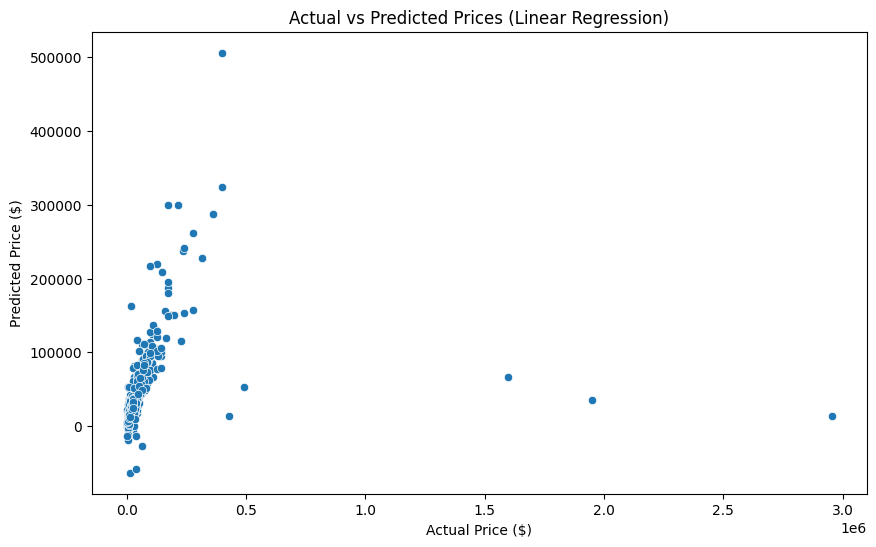

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=linear_predictions)
plt.title("Actual vs Predicted Prices (Linear Regression)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.show()

The Linear Regression baseline model performed weakly on this dataset. It achieved an R² score of about 0.06, meaning it explained only a small part of the variation in used car prices. The RMSE was very high, suggesting that the model made some large prediction errors. This result shows that used car prices may have complex patterns that Linear Regression cannot capture well.

## 11. Model 2: Random Forest Regressor

A Random Forest Regressor is used as the second model. This model combines many decision trees and can capture more complex patterns in used car prices than Linear Regression.

In [59]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_predictions[:10]

array([33360.19, 16072.  , 29684.69, 35428.45, 43342.96, 34293.87,
       46524.06, 54576.77, 18644.69,  9403.57])

In [60]:
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest MSE: {rf_mse:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R²: {rf_r2:.4f}")

Random Forest MAE: 19307.81
Random Forest MSE: 18096399230.79
Random Forest RMSE: 134522.86
Random Forest R²: 0.1146


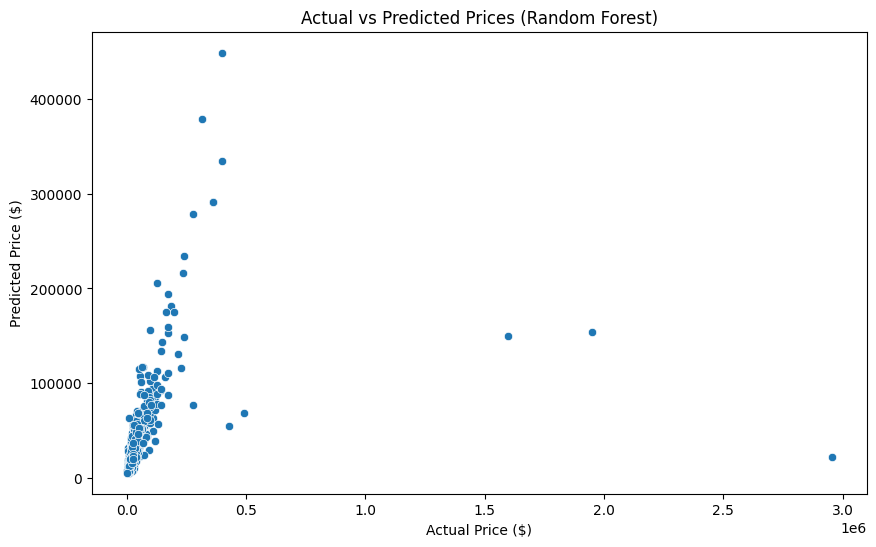

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_predictions)
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.show()

## Outlier Analysis

The first model results showed weak performance and very high RMSE. This may be caused by outliers in the `price` column. In this section, the price distribution is checked to identify unusually high values.

In [62]:
df_clean["price"].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

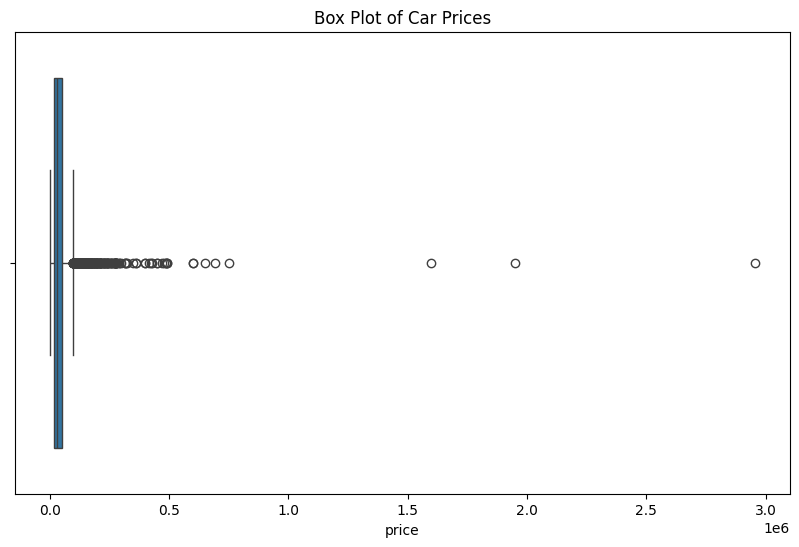

In [63]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_clean["price"])
plt.title("Box Plot of Car Prices")
plt.show()

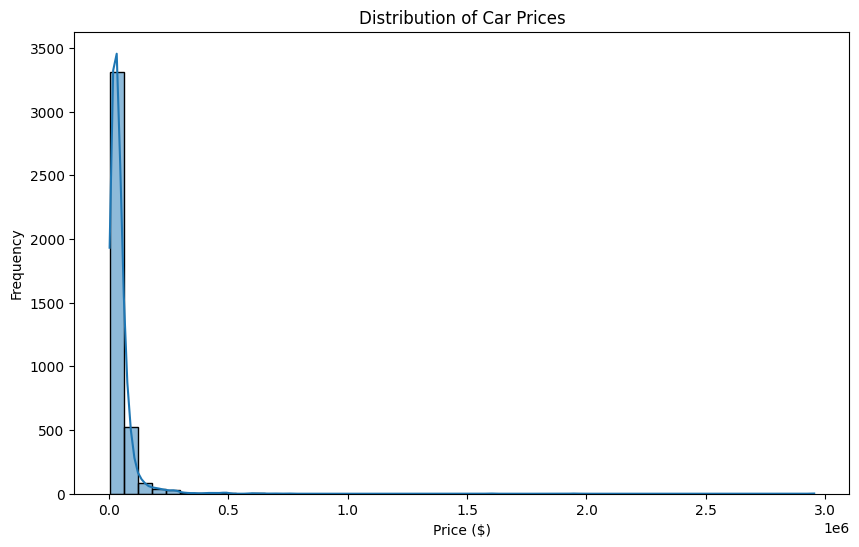

In [65]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean["price"], bins=50, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

In [66]:
df_clean["price"].sort_values(ascending=False).head(10)

693     2954083.0
229     1950995.0
3046    1599000.0
1356     749950.0
624      695000.0
979      649999.0
1615     599995.0
1508     599000.0
3655     491836.0
1061     489995.0
Name: price, dtype: float64

In [68]:
price_99 = df_clean["price"].quantile(0.999)
price_99

np.float64(694639.9920000085)

In [69]:
df_no_outliers = df_clean[df_clean["price"] <= price_99].copy()
df_no_outliers.shape

(4004, 14)

In [70]:
X_no_outliers = df_no_outliers[features]
y_no_outliers = df_no_outliers[target]

X_no_outliers_encoded = pd.get_dummies(X_no_outliers, drop_first=True)
X_no_outliers_encoded = X_no_outliers_encoded.astype(int)

In [71]:
X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(X_no_outliers_encoded, y_no_outliers, test_size=0.2, random_state=42)   

In [72]:
rf_no_outlier_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_no_outlier_model.fit(X_train_no, y_train_no)

rf_no_outlier_predictions = rf_no_outlier_model.predict(X_test_no)
rf_no_outlier_mse = mean_squared_error(y_test_no, rf_no_outlier_predictions)
rf_no_outlier_mae = mean_absolute_error(y_test_no, rf_no_outlier_predictions)
rf_no_outlier_rmse = np.sqrt(rf_no_outlier_mse)
rf_no_outlier_r2 = r2_score(y_test_no, rf_no_outlier_predictions)

print(f"Random Forest (No Outliers) MAE: {rf_no_outlier_mae:.2f}")
print(f"Random Forest (No Outliers) MSE: {rf_no_outlier_mse:.2f}")
print(f"Random Forest (No Outliers) RMSE: {rf_no_outlier_rmse:.2f}")
print(f"Random Forest (No Outliers) R²: {rf_no_outlier_r2:.4f}")

Random Forest (No Outliers) MAE: 11553.68
Random Forest (No Outliers) MSE: 727443614.55
Random Forest (No Outliers) RMSE: 26971.16
Random Forest (No Outliers) R²: 0.6989


After removing the top 1% most expensive cars, the Random Forest model improved significantly. The R² score increased from about 0.11 to 0.70, and RMSE decreased from about 134,523 to about 26,971. This shows that extreme price outliers had a major negative effect on model performance. For this dataset, outlier handling was an important step for building a more reliable used car price prediction model.

## 12. Model Comparison

In this section, the Linear Regression model, Random Forest model, and Random Forest model trained after removing price outliers are compared.

The models are compared using MAE, RMSE, and R² score.

In [73]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Random Forest (No Outliers)"],
    "MAE": [linear_mae, rf_mae, rf_no_outlier_mae],
    "MSE": [linear_mse, rf_mse, rf_no_outlier_mse],
    "RMSE": [linear_rmse, rf_rmse, rf_no_outlier_rmse],
    "R²": [linear_r2, rf_r2, rf_no_outlier_r2]
})

model_results.sort_values(by="R²", ascending=False)

,Model,MAE,MSE,RMSE,R²
2,Random Forest (No Outliers),11553.676142,7.274436e+08,26971.162647,0.698892
1,Random Forest,19307.805810,1.809640e+10,134522.857652,0.114639
0,Linear Regression,19709.319723,1.911819e+10,138268.554395,0.064648


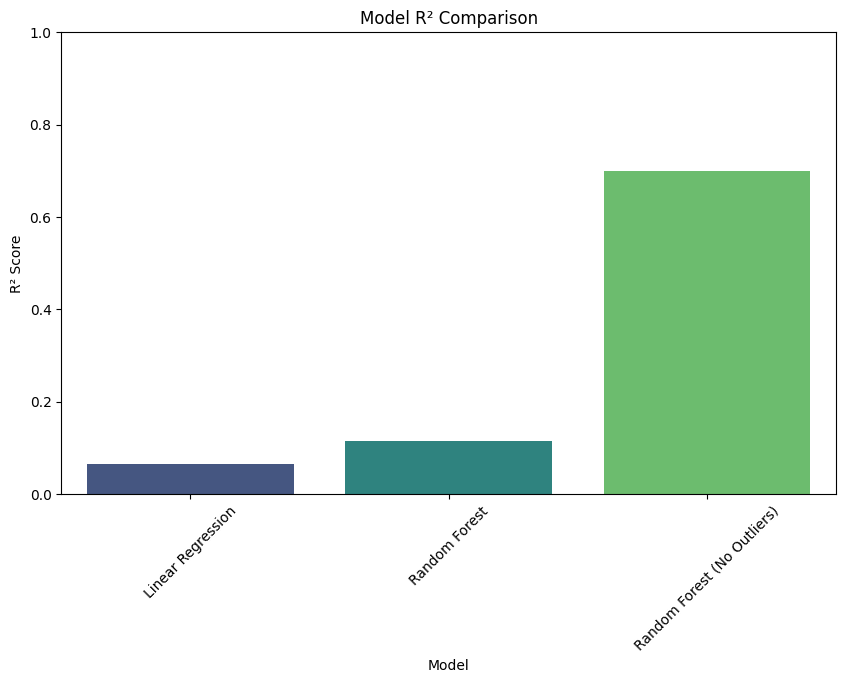

In [74]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", 
            y="R²", 
            data=model_results,
            hue="Model",
            palette="viridis",
            legend=False
            )
plt.title("Model R² Comparison")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

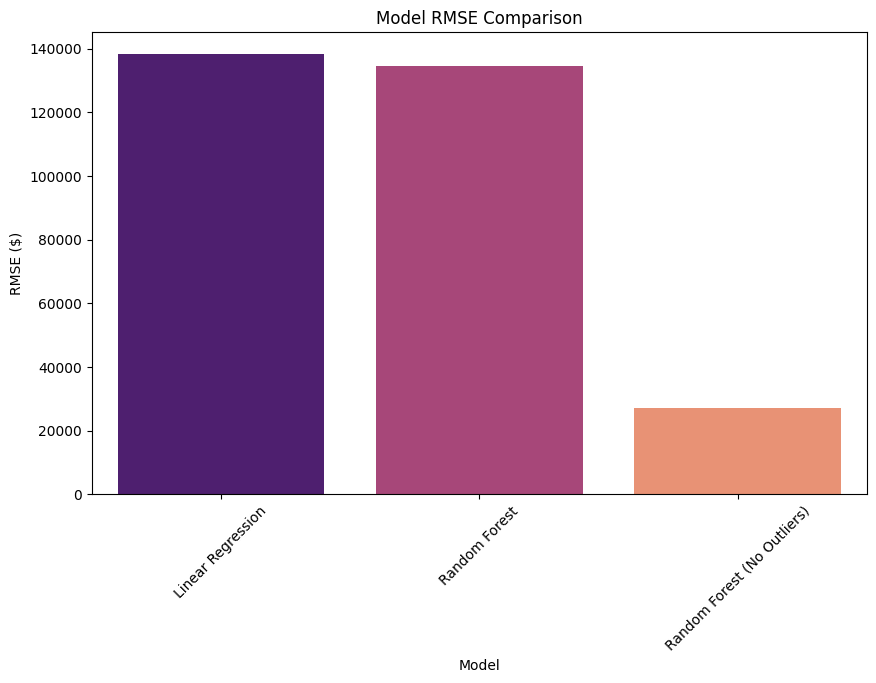

In [75]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Model",
    y="RMSE",
    data=model_results,
    hue="Model",
    palette="magma",
    legend=False
)
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE ($)")
plt.xticks(rotation=45)
plt.show()

The Random Forest model trained after removing the top 1% price outliers performed best. It achieved the highest R² score and the lowest RMSE among the tested models. The large improvement after outlier removal shows that extreme car prices had a strong negative effect on model performance. This confirms that outlier handling was one of the most important steps in this project.

## Best Model

The best model in this project was:

**Random Forest Without Outliers**

This model achieved the strongest performance because it reduced the negative effect of extreme price values and captured more complex patterns in the used car dataset.

## 13. Final Findings

This project focused on predicting used car prices using regression models.

Key findings:

- The dataset contains 4,009 rows and 12 original columns.
- The target column is `price`.
- The `price` and `milage` columns were originally stored as text and needed to be converted into numeric format.
- Missing values were found in `fuel_type`, `accident`, and `clean_title`.
- Missing categorical values were filled with `Unknown`.
- New features were created, including `car_age` and `mileage_per_year`.
- Linear Regression performed weakly, with an R² score of about 0.06.
- Random Forest performed slightly better at first, with an R² score of about 0.11.
- The weak initial results suggested that outliers were strongly affecting model performance.
- After removing the top 1% most expensive cars, the Random Forest model improved significantly.
- Random Forest without outliers achieved an R² score of about 0.70 and RMSE of about 26,971.
- The best model in this project was Random Forest trained after removing price outliers.

Overall, this project showed that outlier handling and feature engineering can have a major impact on regression model performance. The biggest lesson was that improving data quality can be more important than simply changing the machine learning model.